
# Baseline Model 3: Support Vector Machine (SVM) with TF-IDF

Train a Support Vector Machine classifier using TF-IDF features on the IMDb dataset and compare its performance with Naive Bayes and Logistic Regression.

In [1]:
# Step 1: Import libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score
import os


In [2]:
# Step 2: Load preprocessed dataset

# Get the absolute path to the data directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_path = os.path.join(parent_dir, "data", "cleaned_imdb_reviews.csv")

df = pd.read_csv(data_path)

X = df["cleaned_review"]
Y = df["label"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [3]:
# Step 3: TF-IDF coding

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [4]:
# Step 4: Train SVM model

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, Y_train)

Y_pred = svm_model.predict(X_test_tfidf)

Accuracy: 0.8175
Precision: 0.7838
Recall:    0.8744
F1 Score:  0.8266

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.76      0.81       201
           1       0.78      0.87      0.83       199

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



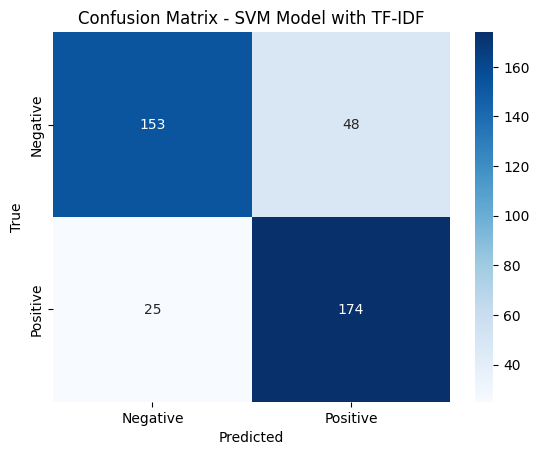

In [5]:
# Step 5: Evaluate the model

precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SVM Model with TF-IDF')
plt.show()